## Podrobna navodila za rešitev naloge

1. Definiramo sezname podatkov v poljubni podatkovni strukturi (npr. "list" ali "numpy.ndarray"). Seznamov naj bo 6, kolikor je stolpcev v zgornji tabeli. V prvem stolpcu je koncentracija acetilholina (v nanomolih/liter), v vseh ostalih pa kontrakcija črevesa (v milimetrih)! Primer definicije podatkovnih struktur:

In [55]:
import numpy as np
kolicina_x = np.array([0,1,3,2.5,4.1,4.5]) # podatkovna struktura numpy.ndarray
kolicina_y1 = (5,10,15,20,25,30) # podatkovna struktura "tuple"
kolicina_y2 = [2,10,3,6,4,5] # podatkova struktura "list"

2.  Na istem grafu izrišemo kontrakcijo vseh 5 meritev (kontrakcija brez atropina in kontrakcija z različnimi koncentracijami atropina) v odvisnosti od koncentracije acetilholina. Splošen primer:

Text(0, 0.5, 'Količina y')

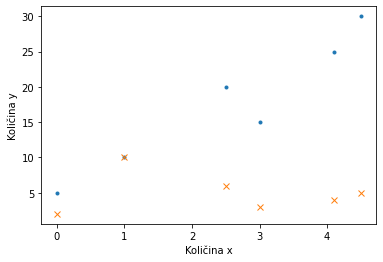

In [56]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots() # inicializacija objektov fig (figure) in ax (axis), na katerih kličemo metode, ki prikazujejo graf
ax.plot(kolicina_x, kolicina_y1, ".", kolicina_x, kolicina_y2, "x") # klic metode "plot", ki izriše y1(x) in y2(x)
ax.set_xlabel("Količina x")
ax.set_ylabel("Količina y")
# plt.show() # pove, da naj se zdaj graf izriše

3. Definiramo modelsko funkcijo. Primer:

In [57]:
def funkcija(x, parameter1, parameter2):
    return parameter1*x + parameter2

4. Podatkom, ki smo jih definirali v koraku 1, prilagodimo (fitamo) funkcijo. Primer:

In [58]:
from scipy.optimize import curve_fit
popt1, pcov1 = curve_fit(funkcija, kolicina_x, kolicina_y1) # v popt1 sta shranjena parameter1 in parameter2 funkcije "funkcija", ki ustrezata podatkom y1(x)
popt2, pcov2 = curve_fit(funkcija, kolicina_x, kolicina_y2) # v popt2 sta shranjena parameter1 in parameter2 funkcije "funkcija", ki ustrezata podatkom y2(x)

5. Na isti graf, kot smo ga narisali zgoraj, lahko zdaj, ko imamo fitane parametre, izrišemo še fitane funkcije. Primer:

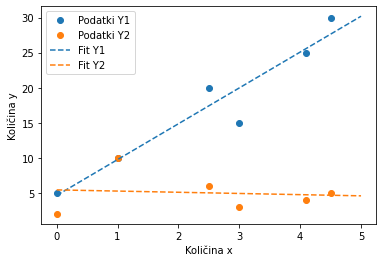

In [67]:
x = np.linspace(0,5,100) # Definiramo podatke na x osi med 0 in 5, ki so bolj gosti (100 vrednosti) kot kolicina_x (v katerem je samo 5 vrednosti)
fig, ax = plt.subplots() # inicializacija objektov fig (figure) in ax (axis), na katerih kličemo metode, ki prikazujejo graf
ax.plot(kolicina_x, kolicina_y1, "o", label="Podatki Y1")
ax.plot(kolicina_x, kolicina_y2, "o", label="Podatki Y2")
ax.plot(x, funkcija(x, *popt1), "C0--", label="Fit Y1") # C0 je default modra barva (prva v vrsti). "--" pomeni črtkana črta
ax.plot(x, funkcija(x, *popt2), "C1--", label="Fit Y2") # C1 je default oranžna barva (druga v vrsti)
ax.set_xlabel("Količina x")
ax.set_ylabel("Količina y")
ax.legend()
plt.show()

6. Za drugi del naloge moramo zapisati sezname novih podatkov. Na x osi bodo koncentracije atropina (so podani – 1e-7, 1e-6 1e-5 in 1e-4), na y osi pa DR-1, ki so odvisni od EC50, ki smo jih zračunali v 4. koraku (shranjeni so v popt). Enako kot prej definirajte nove podatke, novo (linearno) funkcijo in izračunajte fit.